# Project: Smoker Status Prediction

**Overview:** Build a classification model to predict smoker status using demographic and health features from the U.S. health insurance dataset.

**Task:** Binary Classification
**Dataset:** Insurance dataset


## Dataset Description
The dataset variables include:

* age: Age of the beneficiary
* sex: Gender (female/male)
* bmi: Body Mass Index
* children: Number of dependents
* region: Residential region
charges: Medical cost
* smoker: Whether the individual smokes (Target)

The dataset contains a mixture of categorical features (i.e. sex, smoker, region) and numerical features (i.e. age, bmi, children, charges). Handling mixed data types requires appropriate preproccessing such as encoding for categorical fields and scaling for numeric features.

## 1. Imports

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

## 2. Load Dataset

In [102]:
df = pd.read_csv("https://drive.google.com/uc?id=13MqmJ3x_qKazNEnhYrkZ5y0PJywNi5Wb")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Data Exploration

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1335 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


We have 1338 samples with 6 features excluding the 'smoker' column

In [104]:
df.isnull().sum()

,0
age,0
sex,0
bmi,3
children,0
smoker,0
region,0
charges,0


We only have 3 missing values in the 'bmi' column

### Visualizations

#### Target Distribution

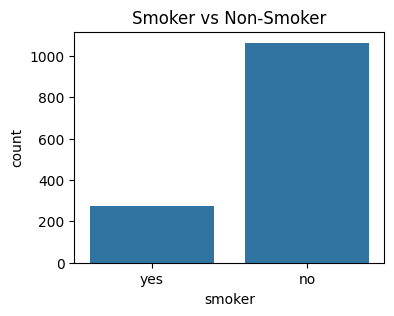

In [105]:
plt.figure(figsize=(4,3))
sns.countplot(data=df, x="smoker")
plt.title("Smoker vs Non-Smoker")
plt.show()

Interpretation:

The bar chart is showing class imbalance in the dataset. The minority class (smokers) is about 20% and the majority class (non-smokers) is about 80%. This impact our Logistic Regression model because it will favor the majority  class.

We will use stratigies like class weighting and focusing on F1-score rather than accuracy in evaluation.

#### Smoker Status by Sex

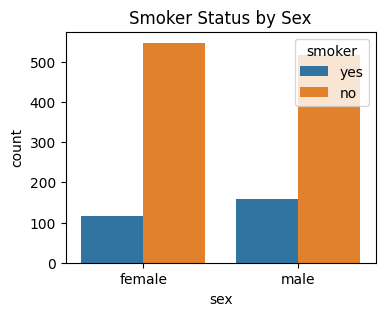

In [106]:
plt.figure(figsize=(4,3))
sns.countplot(data=df, x="sex", hue="smoker")
plt.title("Smoker Status by Sex")
plt.show()

Interpretation:

Both females and males have more non-smokers than smokers. Males are only slightly have more smokers than females in this dataset. Sex maybe useful feature but does not fully separate smokers from non-smokers.

#### Smoker Status by Region

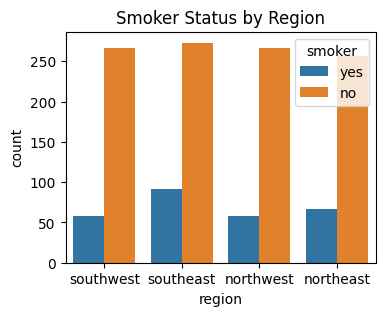

In [107]:
plt.figure(figsize=(4,3))
sns.countplot(data=df, x="region", hue="smoker")
plt.title("Smoker Status by Region")
plt.show()

Interpretation:
All regions show more non-smokers. The southeast has more smokers compared to other regions. Could be a helpful feature.

#### Charges by Smoker Status

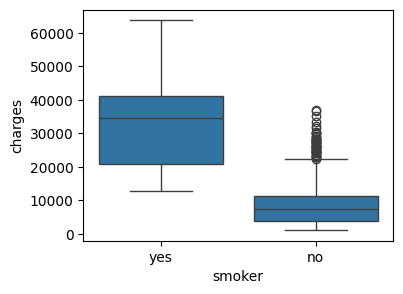

In [108]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=df, x="smoker", y="charges")
plt.show()

Interpretation:

Smoker have much higher medical charges than non-smokers. The separation between groups is strong so charges is a very important predictor.


####BMI Distribution by Smoker Status

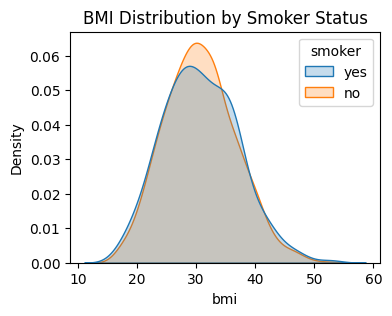

In [109]:
plt.figure(figsize = (4,3))
sns.kdeplot(data=df, x="bmi", hue="smoker", fill=True, common_norm=False)
plt.title("BMI Distribution by Smoker Status")
plt.show()

The BMI distributions overlap almost completely between smokers and non-smokers. BMI alone will not separate classes well.

## 4. Data Preparation

First we will fill missing bmi values with mean:

In [110]:
df["bmi"].fillna(df["bmi"].mean(), inplace = True)

/tmp/ipython-input-360176065.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bmi"].fillna(df["bmi"].mean(), inplace = True)


Next, separate the features from the target variable:

In [111]:
# separate the target

X = df.drop(columns=["smoker"])
y = df["smoker"].map({"yes": 1, "no": 0})

X.head()

,age,sex,bmi,children,region,charges
0,19,female,27.900,0,southwest,16884.92400
1,18,male,33.770,1,southeast,1725.55230
2,28,male,33.000,3,southeast,4449.46200
3,33,male,22.705,0,northwest,21984.47061
4,32,male,28.880,0,northwest,3866.85520


We will use One Hot Encoder for categorical features and apply standard scaler for numerical features since they have very different ranges:

In [112]:
# identify categorical and numerical features

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print(categorical_features, numerical_features)

['sex', 'region'] ['age', 'bmi', 'children', 'charges']


In [113]:
# Preprocessing
categorical_transformer = OneHotEncoder()
numerical_transformer = StandardScaler()

# Column transformer make it easier to do both encoding and scaling in one step
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_features),
        ("numerical", numerical_transformer, numerical_features)
    ]
)
# df = pd.get_dummies(df, columns=categorical_features, drop_first=True, dtype=int)
# scalar = StandardScaler()
# df[numerical_features] = scalar.fit_transform(df[numerical_features])

### Train/Test Split

In [114]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((1070, 6), (268, 6))

## 5. Baseline Model: Logistic Regression

To keep the whole workflow simple and consistent, we will use a pipeline so the same preprocessing is applied every time.

In [115]:
model = LogisticRegression(max_iter=2000)

# We will use a pipeline
baseline_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

baseline_pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(),
                                                  ['sex', 'region']),
                                                 ('numerical', StandardScaler(),
                                                  ['age', 'bmi', 'children',
                                                   'charges'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [116]:
y_pred = baseline_pipe.predict(X_test)

metrics_baseline = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred)
}

metrics_baseline


{'accuracy': 0.9664179104477612,
 'precision': 0.8947368421052632,
 'recall': 0.9444444444444444,
 'f1': 0.918918918918919}

The baseline model already performs very well, especially at identifying smokers (high recall) while keeping good precision.

Results:

Accuracy = 0.966: The model correctly predicts smoker status 96.6% of the time.

Precision = 0.895: When the model predicts smoker "yes", its correct 89.5% of the time.

Recall = 0.944: Of all actual smokers, the model finds 94.4% correctly.

F1 = 0.919: This score combines precision and recall showing balance between catching smokers and avoiding false predictions. We will rely on this metric since our dataset is imbalanced.

Check for class divisions in dataset:

In [117]:
y.value_counts(normalize=True)

,proportion
smoker,
0,0.795217
1,0.204783


The model maybe biased in predicting "non-smoker" so we should monitor recall and F1 and consider class weighting. To address the imbalance, I apply class_weight="balanced" in the Logistic Regression and in the AdaBoost base tree, and I select F1 as the primary selection metric.

## 6. Model Improvements

### Regularization with Grid Search

Instead of guessing the best hyperparameters, Grid Search uses cross-validation to automatically find the best settings for our model.

It will try two regularization types, L1 (Lasso) and L2 (Ridge). It will try different regularization strengths. In our case we will try different values (0.01, 0.1, 10, 100) for C (inverse of regularization strength). Larger C means weaker regularization.

In [118]:
param_grid = {
    "model__penalty" : ["l1", "l2"],
    "model__C" : [0.01, 0.1, 10, 100],
    "model__solver" : ["liblinear"],
}

For this model, we will apply class weighting in Logistic Regression to give heigher weight to smokers (minority class).

We will use Grid Search with 5 cross validation folds. The score to determine the best parameters is F1.

In [119]:
log_reg = LogisticRegression(max_iter=5000, class_weight="balanced")
pipe_grid = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg),
])

grid = GridSearchCV(pipe_grid, param_grid, cv=5, scoring="f1")
grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_

({'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'},
 np.float64(0.9138510378510378))

The best performing Logistic Regression in cross validation used L1 regularization and weaker regularization (C=10). L1 tend to drop unimportant features so this suggests some features maybe less useful. Because C is larger, the model is more flexible so it will generalize better.

In [120]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

metrics_grid_search = {
    "accuracy": accuracy_score(y_test, y_pred_best),
    "precision": precision_score(y_test, y_pred_best),
    "recall": recall_score(y_test, y_pred_best),
    "f1": f1_score(y_test, y_pred_best)
}

metrics_grid_search


{'accuracy': 0.9701492537313433,
 'precision': 0.8709677419354839,
 'recall': 1.0,
 'f1': 0.9310344827586207}

Accuracy = 0.970: Higher overall than baseline.

Precision = 0.871: Lower than baselinem meaning more false postives. (More non-smokers classified as smokers)

Recall = 1.000: The model caught all smokers in the test set!

F1 = 0.931: Higher than baseline so overall balance improved.

This model gives more priority to catch smokers which boost recall and F1. Precision decreased a bit. If missing a smoker is more costly this is the better model.

### AdaBoost

Adaboost is an ensemble method that combines many weak models into a stronger one. It focuses more on the mistakes made in the previous rounds so each new model tries to fix earlier errors.

In our case it uses the default small decision trees with max depth = 1. Class weight is balanced to address the dataset imbalance issue.

In [121]:
base_est = DecisionTreeClassifier(max_depth=1, class_weight="balanced")
ada = AdaBoostClassifier(estimator=base_est, n_estimators=200)

ada_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ada)
])

ada_pipe.fit(X_train, y_train)

y_pred_ada = ada_pipe.predict(X_test)

metrics_ada = {
    "accuracy": accuracy_score(y_test, y_pred_ada),
    "precision": precision_score(y_test, y_pred_ada),
    "recall": recall_score(y_test, y_pred_ada),
    "f1": f1_score(y_test, y_pred_ada)
}

metrics_ada

{'accuracy': 0.9626865671641791,
 'precision': 0.8548387096774194,
 'recall': 0.9814814814814815,
 'f1': 0.9137931034482759}

Accuracy = 0.963: Very high overall accuracy.

Precision = 0.855: When it predicts smoker its correct 85.5% of the time (lower than baseline)

Recall = 0.981: It catches almost all smoker missing few only.

F1 = 0.914: Strong overall balance but below Grid Search Logistic Regression (0.931)

## 7. Model Comparison and Final Answer

In [122]:
results = pd.DataFrame({
    "model": ["Baseline LR", "GridSearch LR", "AdaBoost"],
    "accuracy": [0.9664, 0.9701, 0.9627],
    "precision": [0.8947, 0.8710, 0.8548],
    "recall": [0.9444, 1.000, 0.9815],
    "f1": [0.9189, 0.9310, 0.9138],
})

results

,model,accuracy,precision,recall,f1
0,Baseline LR,0.9664,0.8947,0.9444,0.9189
1,GridSearch LR,0.9701,0.8710,1.0000,0.9310
2,AdaBoost,0.9627,0.8548,0.9815,0.9138


The Baseline Logistic Regression Model is a well balanced model. It maintains strong recall while keeping precision relatively high. It is solid, conservative with no extreme trade offs. Improvement was noticable after Grid Search and dealing with class imbalance. Accuracy, recall and F1 scores increased. Precision decreased so its less conservative in predicting smokers. With Ada Boosting,  Recall improved by focusing on hard samples. However it sacrified precision.

Hyperparameter tuning had more impact with Grid Search Logistic Regression with clear gains in recall and F1. The best choice will be Grid Search Logistic Regression.